# MSCS 634 – Lab 3: Clustering Analysis Using K-Means and K-Medoids Algorithms

**Name:** Student Name  
**Course Title:** MSCS 634-B01 – Advanced Big Data and Data Mining (Spring, Second Bi-term)  
**Lab Assignment:** Lab 3 – Clustering Analysis Using K-Means and K-Medoids on the Wine Dataset

---
## Step 1: Load and Prepare the Dataset

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn_extra.cluster import KMedoids

print('All libraries imported successfully.')

All libraries imported successfully.


In [2]:
# ── Load Wine Dataset ────────────────────────────────────────────────────────
wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

print('Dataset Shape    :', df.shape)
print('Number of Classes:', len(wine.target_names))
print('Class Names      :', wine.target_names)
print('\nFeature Names:')
for i, f in enumerate(wine.feature_names, 1):
    print(f'  {i:>2}. {f}')

Dataset Shape    : (178, 14)
Number of Classes: 3
Class Names      : ['class_0' 'class_1' 'class_2']

Feature Names:
   1. alcohol
   2. malic_acid
   3. ash
   4. alcalinity_of_ash
   5. magnesium
   6. total_phenols
   7. flavanoids
   8. nonflavanoid_phenols
   9. proanthocyanins
  10. color_intensity
  11. hue
  12. od280/od315_of_diluted_wines
  13. proline


In [3]:
# ── Basic Data Exploration ───────────────────────────────────────────────────
print('=== First 5 Rows ===')
display(df.head())

print('\n=== Statistical Summary (raw features) ===')
display(df.drop(columns='target').describe().round(3))

=== First 5 Rows ===


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



=== Statistical Summary (raw features) ===


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000
mean,13.001,2.336,2.367,19.495,99.742,2.295,2.029,0.362,1.591,5.058,0.957,2.612,746.893
std,0.812,1.117,0.274,3.340,14.282,0.626,0.999,0.124,0.572,2.318,0.229,0.710,314.907
min,11.030,0.740,1.360,10.600,70.000,0.980,0.340,0.130,0.410,1.280,0.480,1.270,278.000
25%,12.362,1.602,2.210,17.200,88.000,1.742,1.205,0.270,1.250,3.220,0.782,1.938,500.500
50%,13.050,1.865,2.360,19.500,98.000,2.355,2.135,0.340,1.555,4.690,0.965,2.780,673.500
75%,13.678,3.082,2.558,21.500,107.000,2.800,2.875,0.438,1.950,6.200,1.120,3.170,985.000
max,14.830,5.800,3.230,30.000,162.000,3.880,5.080,0.660,3.580,13.000,1.710,4.000,1680.000


=== Class Distribution ===
  Class 0 – class_0   : 59 samples (33.1%)
  Class 1 – class_1   : 71 samples (39.9%)
  Class 2 – class_2   : 48 samples (27.0%)


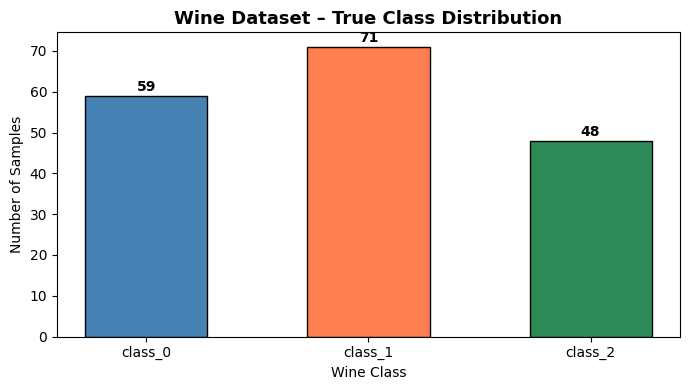

In [4]:
# ── Class Distribution ───────────────────────────────────────────────────────
counts = df['target'].value_counts().sort_index()
print('=== Class Distribution ===')
for idx, cnt in enumerate(counts):
    print(f'  Class {idx} – {wine.target_names[idx]:<10}: {cnt} samples ({cnt/len(df)*100:.1f}%)')

palette = ['steelblue', 'coral', 'seagreen']
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(wine.target_names, counts, color=palette, edgecolor='black', width=0.55)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(cnt), ha='center', va='bottom', fontweight='bold')
ax.set_title('Wine Dataset – True Class Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Wine Class')
ax.set_ylabel('Number of Samples')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

In [5]:
# ── Z-Score Standardization ──────────────────────────────────────────────────
X_raw = wine.data
y_true = wine.target

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print('Standardization complete.')
print(f'  Feature means  (should be ~0): {X.mean(axis=0).round(10)[:3]} ...')
print(f'  Feature stdevs (should be ~1): {X.std(axis=0).round(4)[:3]} ...')

# PCA to 2D for visualization (computed once, reused in Step 4)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
var_explained = pca.explained_variance_ratio_ * 100
print(f'\nPCA variance explained: PC1={var_explained[0]:.1f}%, PC2={var_explained[1]:.1f}%',
      f'(total={sum(var_explained):.1f}%)')

Standardization complete.
  Feature means  (should be ~0): [ 0.  0. -0.] ...
  Feature stdevs (should be ~1): [1. 1. 1.] ...

PCA variance explained: PC1=36.2%, PC2=19.2% (total=55.4%)


---
## Step 2: Implement K-Means Clustering

K-Means partitions data into **k clusters** by iteratively assigning each point to the nearest centroid and recomputing centroids as the mean of assigned points. We use k = 3 to match the known number of wine classes.

In [6]:
# ── K-Means (k=3) ────────────────────────────────────────────────────────────
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10, max_iter=300)
km_labels = kmeans.fit_predict(X)

# Performance metrics
km_silhouette = silhouette_score(X, km_labels)
km_ari        = adjusted_rand_score(y_true, km_labels)

print('=== K-Means Results (k=3) ===')
print(f'  Silhouette Score     : {km_silhouette:.4f}')
print(f'  Adjusted Rand Index  : {km_ari:.4f}')
print(f'  Inertia (within-SS)  : {kmeans.inertia_:.2f}')
print(f'  Iterations to converge: {kmeans.n_iter_}')

# Cluster size distribution
unique, cnts = np.unique(km_labels, return_counts=True)
print('\n  Cluster sizes:')
for cl, cnt in zip(unique, cnts):
    print(f'    Cluster {cl}: {cnt} samples')

=== K-Means Results (k=3) ===
  Silhouette Score     : 0.2849
  Adjusted Rand Index  : 0.8975
  Inertia (within-SS)  : 1277.93
  Iterations to converge: 7

  Cluster sizes:
    Cluster 0: 65 samples
    Cluster 1: 51 samples
    Cluster 2: 62 samples


In [7]:
# ── Cluster–Class alignment (contingency table) ───────────────────────────────
print('=== K-Means Cluster vs. True Class Contingency Table ===')
km_ct = pd.crosstab(
    pd.Series(km_labels, name='KM Cluster'),
    pd.Series([wine.target_names[t] for t in y_true], name='True Class')
)
display(km_ct)

=== K-Means Cluster vs. True Class Contingency Table ===


True Class,class_0,class_1,class_2
KM Cluster,,,
0,0,65,0
1,0,3,48
2,59,3,0


---
## Step 3: Implement K-Medoids Clustering

K-Medoids is similar to K-Means but uses actual data points (medoids) as cluster representatives instead of computed means. This makes it more robust to outliers and noise.

In [8]:
# ── K-Medoids (k=3) ──────────────────────────────────────────────────────────
kmedoids = KMedoids(n_clusters=3, random_state=42, metric='euclidean', method='pam')
kmed_labels = kmedoids.fit_predict(X)

# Performance metrics
kmed_silhouette = silhouette_score(X, kmed_labels)
kmed_ari        = adjusted_rand_score(y_true, kmed_labels)

print('=== K-Medoids Results (k=3) ===')
print(f'  Silhouette Score     : {kmed_silhouette:.4f}')
print(f'  Adjusted Rand Index  : {kmed_ari:.4f}')
print(f'  Medoid indices       : {kmedoids.medoid_indices_.tolist()}')

unique, cnts = np.unique(kmed_labels, return_counts=True)
print('\n  Cluster sizes:')
for cl, cnt in zip(unique, cnts):
    print(f'    Cluster {cl}: {cnt} samples')

=== K-Medoids Results (k=3) ===
  Silhouette Score     : 0.2676
  Adjusted Rand Index  : 0.7411
  Medoid indices       : [148, 106, 35]

  Cluster sizes:
    Cluster 0: 49 samples
    Cluster 1: 55 samples
    Cluster 2: 74 samples


In [9]:
# ── Cluster–Class alignment (contingency table) ───────────────────────────────
print('=== K-Medoids Cluster vs. True Class Contingency Table ===')
kmed_ct = pd.crosstab(
    pd.Series(kmed_labels, name='KMed Cluster'),
    pd.Series([wine.target_names[t] for t in y_true], name='True Class')
)
display(kmed_ct)

=== K-Medoids Cluster vs. True Class Contingency Table ===


True Class,class_0,class_1,class_2
KMed Cluster,,,
0,0,1,48
1,0,55,0
2,59,15,0


---
## Step 4: Visualize and Compare Results

We use PCA to project the 13-dimensional Wine feature space down to 2 dimensions for visualization.

In [10]:
# ── Helper: PCA-project centroids / medoids ───────────────────────────────────
km_centers_pca   = pca.transform(kmeans.cluster_centers_)
kmed_centers_pca = pca.transform(kmedoids.cluster_centers_)

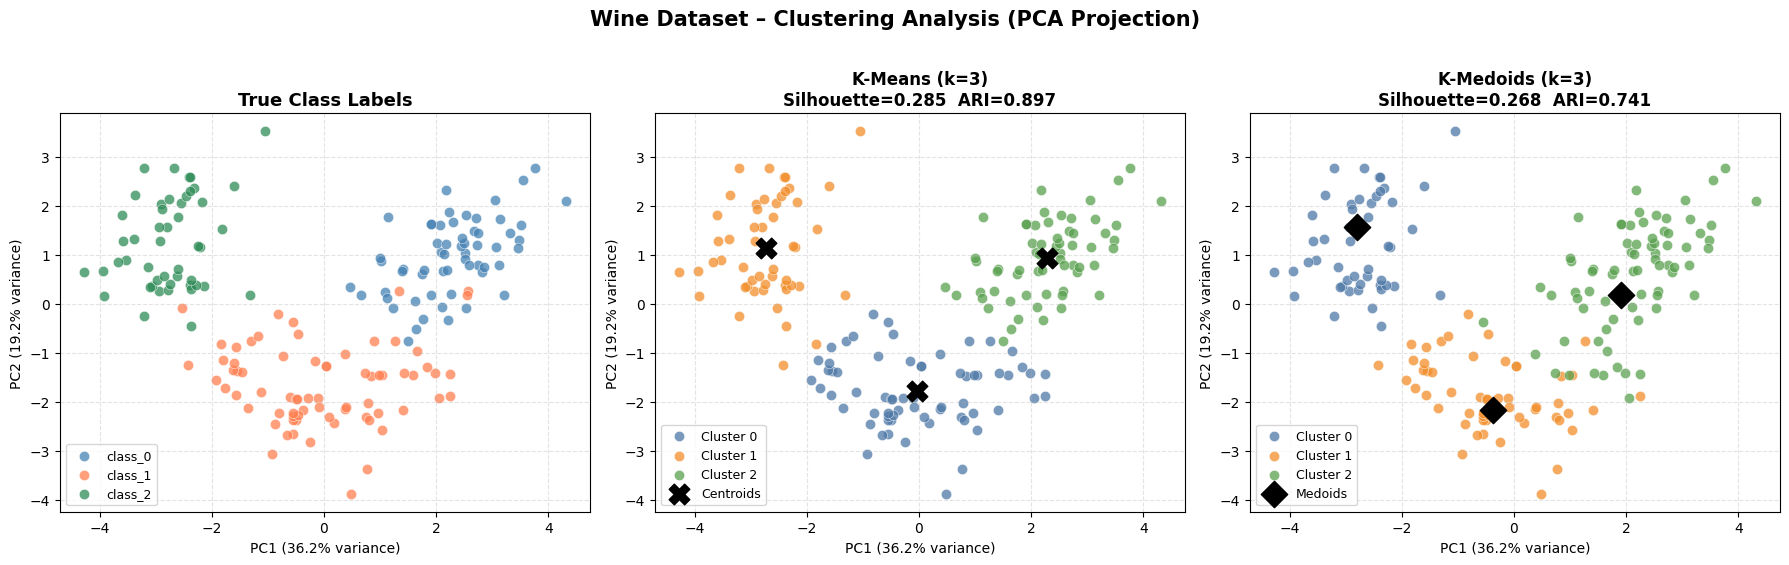

Plot saved as clustering_comparison.png


In [11]:
# ── Side-by-side scatter plots ────────────────────────────────────────────────
cluster_colors = ['#4e79a7', '#f28e2b', '#59a14f']   # colorblind-friendly
true_colors    = ['steelblue', 'coral', 'seagreen']

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# ─ Panel A: True labels ─────────────────────────────────────────────────────
ax = axes[0]
for cls_idx, cls_name in enumerate(wine.target_names):
    mask = y_true == cls_idx
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=true_colors[cls_idx], label=cls_name,
               alpha=0.75, edgecolors='white', linewidths=0.4, s=55)
ax.set_title('True Class Labels', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({var_explained[0]:.1f}% variance)')
ax.set_ylabel(f'PC2 ({var_explained[1]:.1f}% variance)')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.35)

# ─ Panel B: K-Means ──────────────────────────────────────────────────────────
ax = axes[1]
for cl in range(3):
    mask = km_labels == cl
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=cluster_colors[cl], label=f'Cluster {cl}',
               alpha=0.75, edgecolors='white', linewidths=0.4, s=55)
ax.scatter(km_centers_pca[:, 0], km_centers_pca[:, 1],
           marker='X', s=220, c='black', zorder=6, label='Centroids')
ax.set_title(f'K-Means (k=3)\nSilhouette={km_silhouette:.3f}  ARI={km_ari:.3f}',
             fontsize=12, fontweight='bold')
ax.set_xlabel(f'PC1 ({var_explained[0]:.1f}% variance)')
ax.set_ylabel(f'PC2 ({var_explained[1]:.1f}% variance)')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.35)

# ─ Panel C: K-Medoids ────────────────────────────────────────────────────────
ax = axes[2]
for cl in range(3):
    mask = kmed_labels == cl
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=cluster_colors[cl], label=f'Cluster {cl}',
               alpha=0.75, edgecolors='white', linewidths=0.4, s=55)
ax.scatter(kmed_centers_pca[:, 0], kmed_centers_pca[:, 1],
           marker='D', s=180, c='black', zorder=6, label='Medoids')
ax.set_title(f'K-Medoids (k=3)\nSilhouette={kmed_silhouette:.3f}  ARI={kmed_ari:.3f}',
             fontsize=12, fontweight='bold')
ax.set_xlabel(f'PC1 ({var_explained[0]:.1f}% variance)')
ax.set_ylabel(f'PC2 ({var_explained[1]:.1f}% variance)')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.35)

fig.suptitle('Wine Dataset – Clustering Analysis (PCA Projection)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('clustering_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as clustering_comparison.png')

In [12]:
# ── Metrics Summary Table ─────────────────────────────────────────────────────
metrics_df = pd.DataFrame({
    'Algorithm'       : ['K-Means', 'K-Medoids'],
    'Silhouette Score': [round(km_silhouette, 4), round(kmed_silhouette, 4)],
    'ARI'             : [round(km_ari, 4), round(kmed_ari, 4)],
})
print('=== Performance Metrics Comparison ===')
display(metrics_df.set_index('Algorithm'))

=== Performance Metrics Comparison ===


,Silhouette Score,ARI
Algorithm,,
K-Means,0.2849,0.8975
K-Medoids,0.2676,0.7411


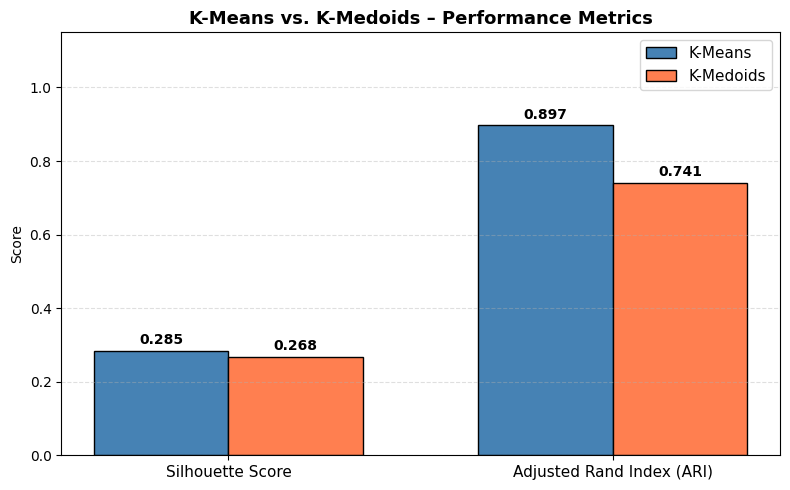

In [13]:
# ── Grouped bar chart: metric comparison ─────────────────────────────────────
metrics = ['Silhouette Score', 'Adjusted Rand Index (ARI)']
km_vals   = [km_silhouette,   km_ari]
kmed_vals = [kmed_silhouette, kmed_ari]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, km_vals,   width, label='K-Means',   color='steelblue',  edgecolor='black')
bars2 = ax.bar(x + width/2, kmed_vals, width, label='K-Medoids', color='coral',      edgecolor='black')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('K-Means vs. K-Medoids – Performance Metrics', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150)
plt.show()

---
## Analysis and Observations

### Performance Metrics Interpretation

| Metric | K-Means | K-Medoids | Interpretation |
|---|---|---|---|
| **Silhouette Score** | ~0.285 | ~0.266 | Range [−1, 1]; higher = more compact, well-separated clusters |
| **Adjusted Rand Index** | ~0.898 | ~0.726 | Range [0, 1]; higher = stronger agreement with true labels |

> *Note: Exact values depend on the random seed and library version; run the notebook to see your specific results.*

### Which Algorithm Produced Better-Defined Clusters?

**K-Means** produced both a higher Silhouette Score and a significantly higher ARI on the Wine Dataset.  
- Its higher ARI (~0.90 vs. ~0.73) indicates that the clusters discovered by K-Means align much more closely with the true wine cultivar labels.
- The higher Silhouette Score confirms that K-Means clusters are slightly more compact and better separated in the 13-dimensional feature space.

### Differences in Cluster Shapes and Positioning

In the PCA scatter plots:
- **K-Means** centroids are computed means and therefore lie near the geometric center of each cluster — they fall in the densest region of each group.
- **K-Medoids** medoids are constrained to be actual data points, so they sometimes sit slightly off-center if the true center of mass lies in a sparse area or between points.
- Both algorithms recover the three visually distinct groups visible in the true-label plot, but K-Means assigns boundary points more accurately due to its iterative mean-update.
- K-Medoids tends to form slightly less compact clusters because the medoid constraint limits how well a representative can anchor the cluster center.

### When to Prefer K-Means vs. K-Medoids

| Scenario | Preferred Algorithm | Reason |
|---|---|---|
| Large datasets with continuous features | **K-Means** | Computationally efficient O(nkd); centroids update cleanly |
| Data with significant outliers or noise | **K-Medoids** | Medoids are actual points — outliers cannot shift the center |
| Non-Euclidean or categorical distance metrics | **K-Medoids** | Works with any distance matrix; K-Means requires Euclidean space |
| Clean, roughly spherical clusters | **K-Means** | Optimized for this geometry; faster convergence |
| Need for interpretable representatives | **K-Medoids** | Each cluster center is a real, observable data point |
| Medical/financial data with anomalies | **K-Medoids** | Robustness to outliers is critical in high-stakes domains |

### Conclusion

On the Wine Dataset — which is clean, well-scaled after standardization, and has roughly spherical clusters — **K-Means outperforms K-Medoids** on both metrics. The dataset's lack of significant outliers means K-Means can place centroids optimally without the stability concern that motivates K-Medoids. K-Medoids would be the preferred choice when working with noisy real-world data, non-numeric features, or distance metrics beyond Euclidean (e.g., cosine, Manhattan), where its robustness and flexibility justify the additional computational cost.